Fetching problems with tag 0-2100 from Codeforces API...
Fetched 11370 problems
Building tag frequencies per rating bucket...

Bucket 0-1000: 2992 tag occurrences across 34 distinct tags
  implementation            658
  math                      594
  greedy                    536
  constructive algorithms   259
  brute force               258
  strings                   167
  sortings                  165
  number theory             81
  dp                        44
  games                     37

Bucket 1000-1300: 3101 tag occurrences across 34 distinct tags
  implementation            569
  greedy                    534
  math                      453
  brute force               279
  constructive algorithms   275
  sortings                  200
  strings                   115
  number theory             100
  dp                        97
  binary search             84

Bucket 1300-1600: 3889 tag occurrences across 36 distinct tags
  greedy                    583
  implementation  

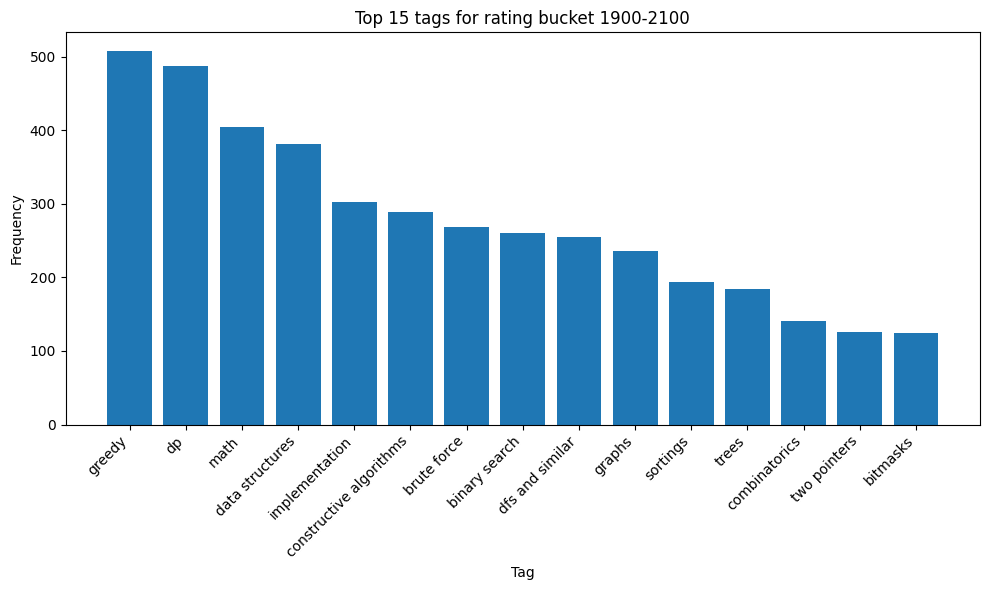

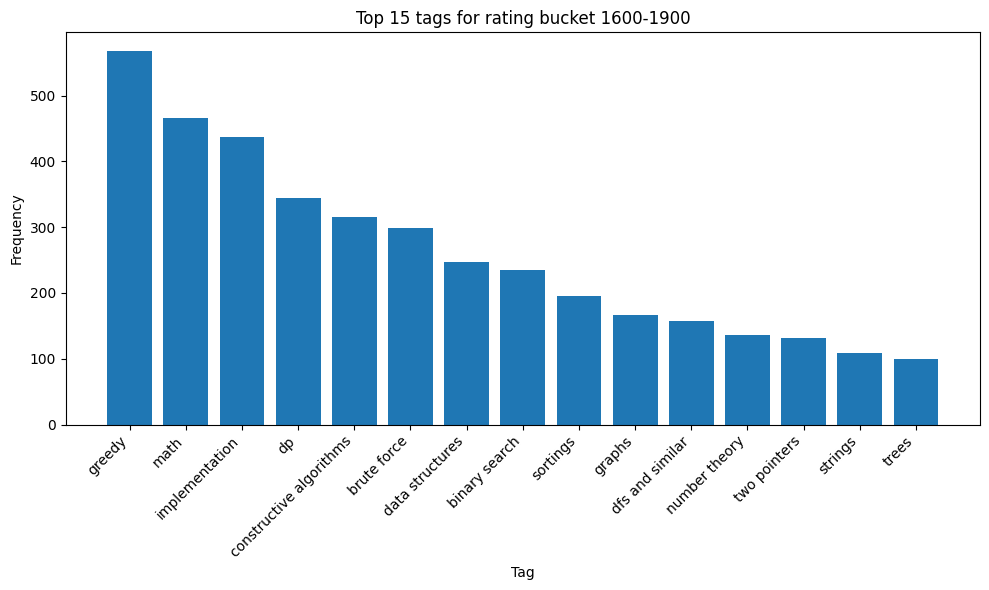

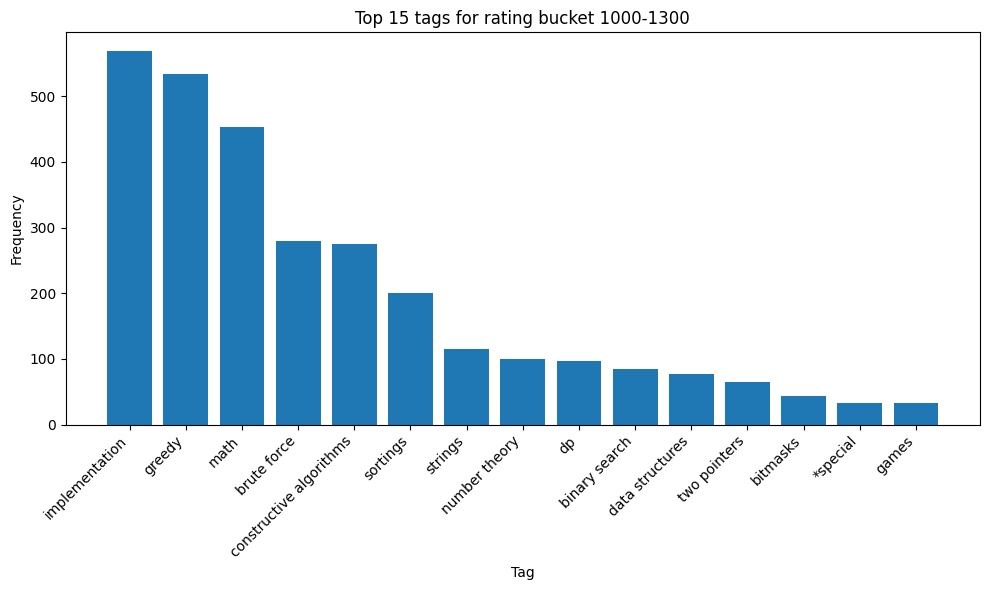

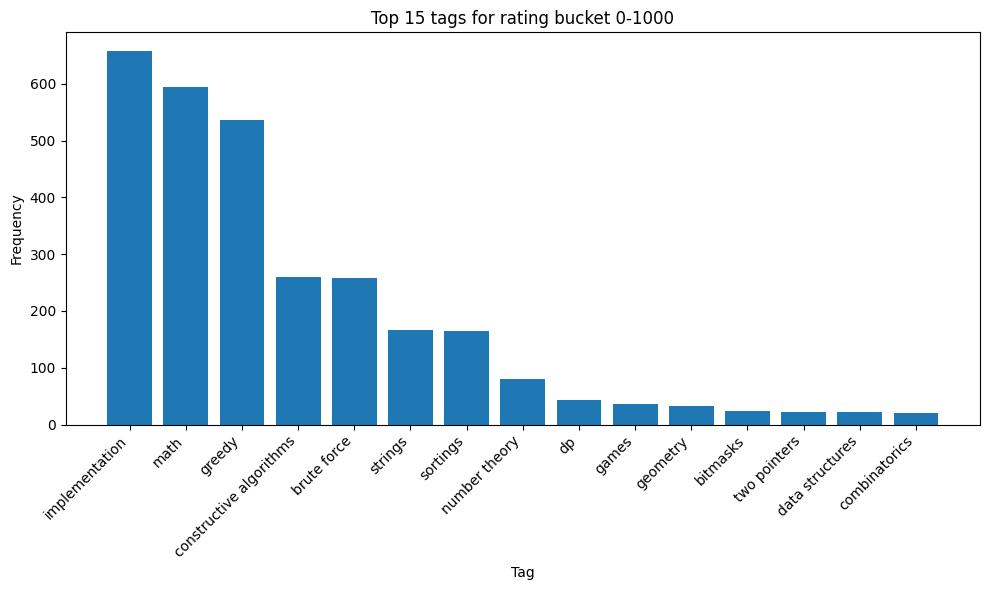

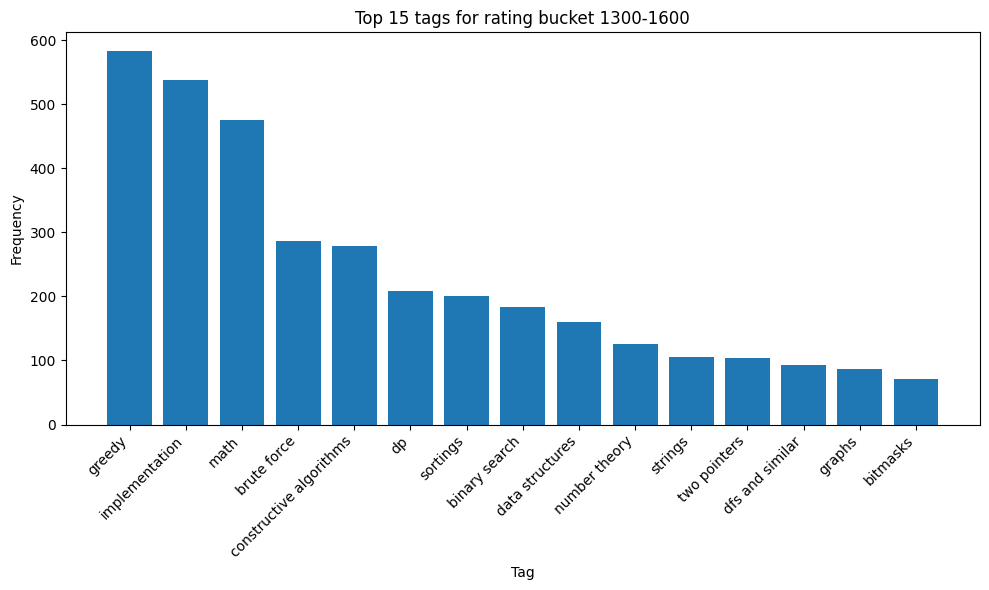

In [1]:
import requests
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

BASE_URL = "https://codeforces.com/api/problemset.problems"

# Rating buckets: (label, lower_bound_inclusive, upper_bound_exclusive)
RATING_BUCKETS = [
    ("0-1000", 0, 1000),
    ("1000-1300", 1000, 1300),
    ("1300-1600", 1300, 1600),
    ("1600-1900", 1600, 1900),
    ("1900-2100", 1900, 2101),  # 2100 inclusive
]

def get_bucket_label(rating: int):
    """Return the label of the bucket that rating belongs to, or None if outside."""
    if rating is None:
        return None
    for label, lo, hi in RATING_BUCKETS:
        if lo <= rating < hi:
            return label
    return None

def fetch_problems_0_2100():
    """
    Uses Codeforces API to fetch problems with tag '0-2100' (i.e., problems
    up to 2100 difficulty).
    """
    resp = requests.get(BASE_URL)
    resp.raise_for_status()
    data = resp.json()

    if data.get("status") != "OK":
        raise RuntimeError(f"Codeforces API error: {data}")

    return data["result"]["problems"]

def build_tag_frequencies_by_bucket(problems):
    """
    Given a list of problems from the API, return:
        bucket_to_tag_counter: dict[label -> Counter(tag -> freq)]
    """
    bucket_to_tag_counter: dict[str, Counter] = defaultdict(Counter)

    for p in problems:
        rating = p.get("rating")
        tags = p.get("tags", [])
        bucket_label = get_bucket_label(rating)
        if bucket_label is None:
            continue  # skip problems outside buckets or without rating

        for t in tags:
            bucket_to_tag_counter[bucket_label][t] += 1

    return bucket_to_tag_counter

def plot_tag_barcharts(bucket_to_tag_counter, top_n: int = 15):
    """
    For each bucket, show a bar chart of the top_n tags by frequency.
    """
    for bucket_label, counter in bucket_to_tag_counter.items():
        if not counter:
            print(f"No data for bucket {bucket_label}, skipping plot.")
            continue

        # Take top N tags
        most_common = counter.most_common(top_n)
        tags = [t for t, _ in most_common]
        freqs = [f for _, f in most_common]

        plt.figure(figsize=(10, 6))
        plt.bar(tags, freqs)
        plt.xticks(rotation=45, ha="right")
        plt.title(f"Top {top_n} tags for rating bucket {bucket_label}")
        plt.xlabel("Tag")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()
        # Or save instead of show:
        # plt.savefig(f"tags_{bucket_label}.png", bbox_inches="tight")

def main():
    print("Fetching problems with tag 0-2100 from Codeforces API...")
    problems = fetch_problems_0_2100()
    print(f"Fetched {len(problems)} problems")

    print("Building tag frequencies per rating bucket...")
    bucket_to_tag_counter = build_tag_frequencies_by_bucket(problems)

    # Print some stats:
    for label, _, _ in RATING_BUCKETS:
        cnt = bucket_to_tag_counter.get(label, Counter())
        print(f"\nBucket {label}: {sum(cnt.values())} tag occurrences across {len(cnt)} distinct tags")
        for tag, freq in cnt.most_common(10):
            print(f"  {tag:25s} {freq}")

    print("\nPlotting bar charts...")
    plot_tag_barcharts(bucket_to_tag_counter, top_n=15)

if __name__ == "__main__":
    main()
